# End-to-End Usage Example
This notebook demonstrates a full workflow for `transform_emr`: install/import, data preparation, train/load (Phase 1 + Phase 2), and evaluation.

In [1]:
%pip install -e .

Obtaining file:///C:/Users/shaha/Work/Personal/Transform-EMR
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Checking if build backend supports build_editable: started
  Checking if build backend supports build_editable: finished with status 'done'
  Getting requirements to build editable: started
  Getting requirements to build editable: finished with status 'done'
  Preparing editable metadata (pyproject.toml): started
  Preparing editable metadata (pyproject.toml): finished with status 'done'
  Building editable for transform_emr (pyproject.toml): started
  Building editable for transform_emr (pyproject.toml): finished with status 'done'
  Created wheel for transform_emr: filename=transform_emr-0.1-0.editable-py3-none-any.whl size=3982 sha256=e761a2ed3112a3a1bc8171d013feab180a87941fb45901db8822a74802abb75b
  Stored in directory: C:\Users\shaha\AppData\Local\Temp\pip-ephem-wheel-cache-i41c4_lj\wheels\6d\6c\f9\48dfb1d8b6464f43416

In [9]:
import importlib
import random
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

PROJECT_ROOT = Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import transform_emr.config.dataset_config as dataset_config
import transform_emr.config.model_config as model_config
from transform_emr import dataset, embedder, transformer, inference

for module in (
    dataset_config,
    model_config,
    dataset,
    embedder,
    transformer,
    inference,
 ):
    importlib.reload(module)

print("Reloaded config and modules. Re-run this cell after changing *_config.py or module code.")
print(f"Project root: {PROJECT_ROOT}")

Reloaded config and modules. Re-run this cell after changing *_config.py or module code.
Project root: C:\Users\shaha\Work\Personal\Transform-EMR


In [ ]:
# Optional cleanup controls for checkpoint artifacts (useful on restricted VMs)
CLEAN_SCALER = False
CLEAN_TOKENIZER = False
CLEAN_EMBEDDER = False
CLEAN_TRANSFORMER = False

# Convenience switch: if True, cleans all artifacts above
CLEAN_ALL = False

clean_scaler = CLEAN_SCALER or CLEAN_ALL
clean_tokenizer = CLEAN_TOKENIZER or CLEAN_ALL
clean_embedder = CLEAN_EMBEDDER or CLEAN_ALL
clean_transformer = CLEAN_TRANSFORMER or CLEAN_ALL

paths_to_delete = []

if clean_scaler:
    paths_to_delete.append(Path(model_config.CHECKPOINT_PATH) / "scaler.pkl")
if clean_tokenizer:
    paths_to_delete.append(Path(model_config.CHECKPOINT_PATH) / "tokenizer.pt")
if clean_embedder:
    embedder_ckpt = Path(model_config.EMBEDDER_CHECKPOINT).resolve()
    paths_to_delete.extend([embedder_ckpt, embedder_ckpt.parent / "ckpt_last.pt"])
if clean_transformer:
    transformer_ckpt = Path(model_config.TRANSFORMER_CHECKPOINT).resolve()
    paths_to_delete.extend([transformer_ckpt, transformer_ckpt.parent / "ckpt_last.pt"])

if not paths_to_delete:
    print("No cleanup selected. Set CLEAN_* = True (or CLEAN_ALL = True) and re-run this cell.")
else:
    removed, missing, failed = [], [], []
    for path in dict.fromkeys(paths_to_delete):  # dedupe while preserving order
        try:
            if path.exists():
                path.unlink()
                removed.append(path)
            else:
                missing.append(path)
        except Exception as exc:
            failed.append((path, str(exc)))

    print("Checkpoint cleanup summary:")
    print(f"  Removed: {len(removed)}")
    for path in removed:
        print(f"    - {path}")

    print(f"  Not found: {len(missing)}")
    for path in missing:
        print(f"    - {path}")

    if failed:
        print(f"  Failed: {len(failed)}")
        for path, err in failed:
            print(f"    - {path} -> {err}")

## 1) Data Load and Processing

In [ ]:
# Choose data source mode:
# - "pre_split": use dataset_config TRAIN_* for train and TEST_* for evaluation
# - "source_split": load from data/source and split by PatientId
DATA_SOURCE_MODE = "pre_split"  # "pre_split" | "source_split"

if DATA_SOURCE_MODE not in {"pre_split", "source_split"}:
    raise ValueError("DATA_SOURCE_MODE must be 'pre_split' or 'source_split'.")

# Used only when DATA_SOURCE_MODE == "source_split"
SOURCE_TEMPORAL_DATA_FILE = PROJECT_ROOT / "data" / "source" / "synthetic_diabetes_temporal_data.csv"
SOURCE_CTX_DATA_FILE = PROJECT_ROOT / "data" / "source" / "synthetic_diabetes_context_data.csv"
SOURCE_TEST_SIZE = 0.2
SOURCE_SPLIT_SEED = 42

# Train/val split (applied on the train pool in both modes)
TRAIN_VAL_SIZE = 0.2
TRAIN_VAL_SPLIT_SEED = 42

# Optional train-patient sampling for faster local runs (None = all patients)
SAMPLE_PATIENTS = None
NUM_WORKERS = 4 if SAMPLE_PATIENTS is None else 0  # use single worker if sampling to avoid overhead

# Tokenizer behavior (existing tokenizer is reused if present)
TOKENIZER_PATH = Path(model_config.CHECKPOINT_PATH) / "tokenizer.pt"

# "train_only" | "train_val" | "all_processed" (recommended)
TOKENIZER_FIT_SCOPE = "all_processed"
if TOKENIZER_FIT_SCOPE not in {"train_only", "train_val", "all_processed"}:
    raise ValueError("TOKENIZER_FIT_SCOPE must be 'train_only', 'train_val', or 'all_processed'.")

# Optional safety: auto-sync MODEL_CONFIG ctx_dim from processed train context
AUTO_SET_CTX_DIM = True

# Evaluation settings used later
K_RANGE = range(3, 8)
MAX_LEN = 1000
TEMPERATURE = 1.0
TIME_BIAS_HOURS = 48

print(f"Data mode: {DATA_SOURCE_MODE}")

# Load data according to the selected mode
if DATA_SOURCE_MODE == "pre_split":
    train_temporal_raw = pd.read_csv(dataset_config.TRAIN_TEMPORAL_DATA_FILE, low_memory=False)
    train_ctx_raw = pd.read_csv(dataset_config.TRAIN_CTX_DATA_FILE)
    eval_temporal_raw = pd.read_csv(dataset_config.TEST_TEMPORAL_DATA_FILE, low_memory=False)
    eval_ctx_raw = pd.read_csv(dataset_config.TEST_CTX_DATA_FILE)
else:
    if not SOURCE_TEMPORAL_DATA_FILE.exists() or not SOURCE_CTX_DATA_FILE.exists():
        raise FileNotFoundError(
            f"Source files not found:\n- {SOURCE_TEMPORAL_DATA_FILE}\n- {SOURCE_CTX_DATA_FILE}"
        )

    source_temporal_raw = pd.read_csv(SOURCE_TEMPORAL_DATA_FILE, low_memory=False)
    source_ctx_raw = pd.read_csv(SOURCE_CTX_DATA_FILE)

    source_pids = source_temporal_raw["PatientId"].dropna().unique()
    train_pool_ids, eval_ids = train_test_split(
        source_pids, test_size=SOURCE_TEST_SIZE, random_state=SOURCE_SPLIT_SEED
    )

    train_temporal_raw = source_temporal_raw[source_temporal_raw["PatientId"].isin(train_pool_ids)].copy()
    train_ctx_raw = source_ctx_raw[source_ctx_raw["PatientId"].isin(train_pool_ids)].copy()

    eval_temporal_raw = source_temporal_raw[source_temporal_raw["PatientId"].isin(eval_ids)].copy()
    eval_ctx_raw = source_ctx_raw[source_ctx_raw["PatientId"].isin(eval_ids)].copy()

    # Save the splits for reproducibility and inspection
    train_temporal_raw.to_csv(dataset_config.TRAIN_TEMPORAL_DATA_FILE, index=False)
    train_ctx_raw.to_csv(dataset_config.TRAIN_CTX_DATA_FILE, index=False)
    eval_temporal_raw.to_csv(dataset_config.TEST_TEMPORAL_DATA_FILE, index=False)
    eval_ctx_raw.to_csv(dataset_config.TEST_CTX_DATA_FILE, index=False)

# Optional patient sampling for faster iterations
if SAMPLE_PATIENTS is not None:
    unique_train_pids = train_temporal_raw["PatientId"].dropna().unique()
    if SAMPLE_PATIENTS > len(unique_train_pids):
        raise ValueError(f"SAMPLE_PATIENTS={SAMPLE_PATIENTS} is larger than available patients={len(unique_train_pids)}")
    sampled_ids = sorted(random.sample(list(unique_train_pids), SAMPLE_PATIENTS))
    train_temporal_raw = train_temporal_raw[train_temporal_raw["PatientId"].isin(sampled_ids)].copy()
    train_ctx_raw = train_ctx_raw[train_ctx_raw["PatientId"].isin(sampled_ids)].copy()

# Split train pool into train/val by PatientId
train_pool_pids = train_temporal_raw["PatientId"].dropna().unique()
train_ids, val_ids = train_test_split(
    train_pool_pids, test_size=TRAIN_VAL_SIZE, random_state=TRAIN_VAL_SPLIT_SEED
)

train_temporal_split = train_temporal_raw[train_temporal_raw["PatientId"].isin(train_ids)].copy()
train_ctx_split = train_ctx_raw[train_ctx_raw["PatientId"].isin(train_ids)].copy()
val_temporal_split = train_temporal_raw[train_temporal_raw["PatientId"].isin(val_ids)].copy()
val_ctx_split = train_ctx_raw[train_ctx_raw["PatientId"].isin(val_ids)].copy()

print("Processing train split (fits scaler)...")
train_processor = dataset.DataProcessor(
    train_temporal_split,
    train_ctx_split,
    scaler=None,
    tak_repo_path=dataset_config.TAK_REPO_PATH,
    checkpoint_path=model_config.CHECKPOINT_PATH,
 )
train_temporal_df, train_ctx_df = train_processor.run()

scaler_path = Path(model_config.CHECKPOINT_PATH) / "scaler.pkl"
if not scaler_path.exists():
    raise FileNotFoundError(f"Expected scaler at {scaler_path}")
scaler = joblib.load(scaler_path)

print("Processing val split (uses fitted scaler)...")
val_processor = dataset.DataProcessor(
    val_temporal_split,
    val_ctx_split,
    scaler=scaler,
    tak_repo_path=dataset_config.TAK_REPO_PATH,
    checkpoint_path=model_config.CHECKPOINT_PATH,
 )
val_temporal_df, val_ctx_df = val_processor.run()

print("Processing eval split (uses fitted scaler)...")
eval_processor = dataset.DataProcessor(
    eval_temporal_raw.copy(),
    eval_ctx_raw.copy(),
    scaler=scaler,
    tak_repo_path=dataset_config.TAK_REPO_PATH,
    checkpoint_path=model_config.CHECKPOINT_PATH,
 )
eval_temporal_df, eval_ctx_df = eval_processor.run()

if TOKENIZER_PATH.exists():
    print(f"Loading tokenizer from: {TOKENIZER_PATH}")
    tokenizer = dataset.EMRTokenizer.load(TOKENIZER_PATH)
else:
    if TOKENIZER_FIT_SCOPE == "train_only":
        tokenizer_fit_df = train_temporal_df
    elif TOKENIZER_FIT_SCOPE == "train_val":
        tokenizer_fit_df = pd.concat([train_temporal_df, val_temporal_df], ignore_index=True)
    else:
        tokenizer_fit_df = pd.concat([train_temporal_df, val_temporal_df, eval_temporal_df], ignore_index=True)

    print(
        "Building tokenizer from "
        f"{TOKENIZER_FIT_SCOPE} data: "
        f"{tokenizer_fit_df['PatientId'].nunique()} patients, "
        f"{tokenizer_fit_df['PositionToken'].nunique()} unique position tokens"
    )
    tokenizer = dataset.EMRTokenizer.from_processed_df(tokenizer_fit_df)
    tokenizer.save(TOKENIZER_PATH)
    print(f"Saved tokenizer to: {TOKENIZER_PATH}")

train_ds = dataset.EMRDataset(train_temporal_df, train_ctx_df, tokenizer=tokenizer)
val_ds = dataset.EMRDataset(val_temporal_df, val_ctx_df, tokenizer=tokenizer)
eval_ds = dataset.EMRDataset(eval_temporal_df, eval_ctx_df, tokenizer=tokenizer)

if AUTO_SET_CTX_DIM:
    model_config.MODEL_CONFIG["ctx_dim"] = int(train_ds.context_df.shape[1])
    print(f"Updated MODEL_CONFIG['ctx_dim'] -> {model_config.MODEL_CONFIG['ctx_dim']}")
else:
    assert train_ds.context_df.shape[1] == model_config.MODEL_CONFIG["ctx_dim"], (
        f"Context dimension mismatch: expected {model_config.MODEL_CONFIG['ctx_dim']}, got {train_ds.context_df.shape[1]}"
    )

embedder_train_dl = dataset.get_dataloader(
    train_ds,
    batch_size=model_config.TRAINING_SETTINGS["batch_size"],
    collate_fn=dataset.collate_emr,
    oversample=False,
    num_workers=NUM_WORKERS,
 )
transformer_train_dl = dataset.get_dataloader(
    train_ds,
    batch_size=model_config.TRAINING_SETTINGS["batch_size"],
    collate_fn=dataset.collate_emr,
    oversample=True,
    num_workers=NUM_WORKERS,
 )
val_dl = dataset.get_dataloader(
    val_ds,
    batch_size=model_config.TRAINING_SETTINGS["batch_size"],
    collate_fn=dataset.collate_emr,
    oversample=False,
    num_workers=NUM_WORKERS,
 )

print(f"Train patients: {len(train_ids)} | Val patients: {len(val_ids)} | Eval patients: {eval_temporal_df['PatientId'].nunique()}")
print(f"Train records: {len(train_ds.tokens_df):,} | Val records: {len(val_ds.tokens_df):,} | Eval records: {len(eval_ds.tokens_df):,}")

Data mode: pre_split
Processing train split (fits scaler)...
Processing val split (uses fitted scaler)...
Processing eval split (uses fitted scaler)...
Building tokenizer from processed train split...
Updated MODEL_CONFIG['ctx_dim'] -> 2
Train patients: 400 | Val patients: 100 | Eval patients: 100
Train records: 34,045 | Val records: 6,418 | Eval records: 8,485


## 2) Training

In [4]:
# Training / loading controls
LOAD_LAST_CHECKPOINT_IF_AVAILABLE = True
RESUME_TRAINING = True

RUN_PHASE1 = True
RUN_PHASE2 = True

print("Training controls set.")
print(f"RUN_PHASE1={RUN_PHASE1}, RUN_PHASE2={RUN_PHASE2}, RESUME_TRAINING={RESUME_TRAINING}")

Training controls set.
RUN_PHASE1=True, RUN_PHASE2=True, RESUME_TRAINING=True


Initializing new embedder.
Running Phase 1 training...


[Phase-1] Epoch 001
            --> Train=4.9911 (BCE=3.6300  MLM=1.3428  Δt=0.0183)
            --> Val=4.8310 (BCE=3.5214  MLM=1.2920  Δt=0.0175)


[Phase-1] Epoch 002
            --> Train=4.7012 (BCE=3.4126  MLM=1.2713  Δt=0.0174)
            --> Val=4.4562 (BCE=3.2845  MLM=1.1551  Δt=0.0167)


[Phase-1] Epoch 003
            --> Train=4.3540 (BCE=3.1894  MLM=1.1481  Δt=0.0164)
            --> Val=4.1493 (BCE=3.0788  MLM=1.0547  Δt=0.0158)


[Phase-1] Epoch 004
            --> Train=4.0662 (BCE=2.9905  MLM=1.0602  Δt=0.0155)
            --> Val=3.9117 (BCE=2.9029  MLM=0.9939  Δt=0.0150)


...

[Phase-1] Epoch 096
            --> Train=0.5905 (BCE=0.4270  MLM=0.1628  Δt=0.0007)
            --> Val=0.4636 (BCE=0.3202  MLM=0.1426  Δt=0.0007)


[Phase-1] Epoch 097
            --> Train=0.6036 (BCE=0.4174  MLM=0.1856  Δt=0.0007)
            --> Val=0.4619 (BCE=0.3231  MLM=0.1380  Δt=0.0008)


[Phase-1] Epoch 098
            --> Train=0.5877 (BCE=0.4167  MLM=0.1703  Δt=0.0006)
            --> Val=0.4689 (BCE=0.3151  MLM=0.1531  Δt=0.0007)


[Phase-1] Epoch 099
            --> Train=0.5778 (BCE=0.4119  MLM=0.1653  Δt=0.0006)
            --> Val=0.4551 (BCE=0.3155  MLM=0.1389  Δt=0.0007)
[Phase-1]: Current best model saved.


[Phase-1] Epoch 100
            --> Train=0.6027 (BCE=0.4275  MLM=0.1745  Δt=0.0006)
            --> Val=0.4516 (BCE=0.3141  MLM=0.1367  Δt=0.0008)
[Phase-1]: Current best model saved.


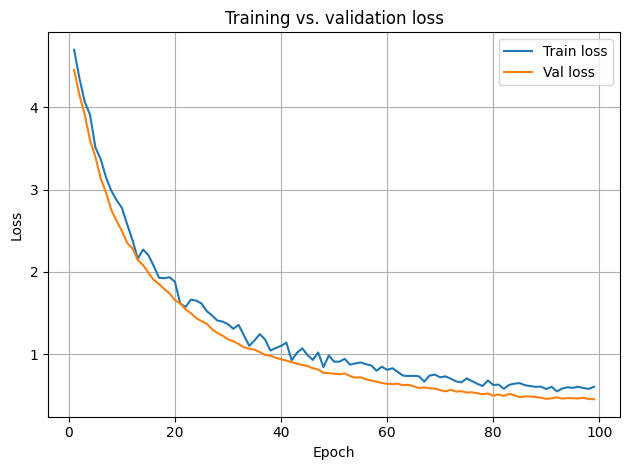

Initializing new transformer model.
[GPT]: Total params: 0.45 M
Running Phase 2 training...
[Phase-2]: Starting transformer training loop...


[Phase-2]: Epoch 00
        --> Train=0.6300 (BCE=0.0140, CE=0.5195, Pen=0.0000, Out=0.0000, Δt=0.0965)
        --> Val=0.6268 (BCE=0.0135, CE=0.5169, Pen=0.0000, Out=0.0000, Δt=0.0964)
        --> Val-F1  RELEASE:0.0000  DEATH:0.0000  COMPLICATION:0.0000


[Phase-2]: Epoch 01
        --> Train=0.6284 (BCE=0.0140, CE=0.5182, Pen=0.0000, Out=0.0000, Δt=0.0961)
        --> Val=0.6276 (BCE=0.0135, CE=0.5182, Pen=0.0000, Out=0.0000, Δt=0.0959)
        --> Val-F1  RELEASE:0.0000  DEATH:0.0000  COMPLICATION:0.0000


[Phase-2]: Epoch 02
        --> Train=0.6287 (BCE=0.0141, CE=0.5190, Pen=0.0000, Out=0.0000, Δt=0.0956)
        --> Val=0.6245 (BCE=0.0135, CE=0.5156, Pen=0.0000, Out=0.0000, Δt=0.0953)
        --> Val-F1  RELEASE:0.0000  DEATH:0.0000  COMPLICATION:0.0000


[Phase-2]: Epoch 03
        --> Train=0.6275 (BCE=0.0139, CE=0.5189, Pen=0.0000, Out=0.0000, Δt=0.0947)
        --> Val=0.6232 (BCE=0.0135, CE=0.5155, Pen=0.0000, Out=0.0000, Δt=0.0942)
        --> Val-F1  RELEASE:0.0000  DEATH:0.0000  COMPLICATION:0.0000


...

[Phase-2]: Epoch 11
        --> Train=2.5975 (BCE=0.0130, CE=0.4986, Pen=0.0823, Out=1.9667, Δt=0.0368)
        --> Val=1.9642 (BCE=0.0127, CE=0.4963, Pen=0.0804, Out=1.3481, Δt=0.0267)
        --> Val-F1  RELEASE:0.0000  DEATH:0.0000  COMPLICATION:0.0000


[Phase-2]: Epoch 12
        --> Train=2.8260 (BCE=0.0128, CE=0.4934, Pen=0.0818, Out=2.2152, Δt=0.0229)
        --> Val=2.2278 (BCE=0.0126, CE=0.4933, Pen=0.0807, Out=1.6240, Δt=0.0171)
        --> Val-F1  RELEASE:0.0000  DEATH:0.0000  COMPLICATION:0.0000


[Phase-2]: Epoch 13
        --> Train=2.5596 (BCE=0.0127, CE=0.4917, Pen=0.0819, Out=1.9587, Δt=0.0146)
        --> Val=2.4765 (BCE=0.0125, CE=0.4914, Pen=0.0802, Out=1.8818, Δt=0.0106)
        --> Val-F1  RELEASE:0.0000  DEATH:0.0000  COMPLICATION:0.0000


[Phase-2]: Epoch 14
        --> Train=2.8227 (BCE=0.0125, CE=0.4892, Pen=0.0828, Out=2.2292, Δt=0.0089)
        --> Val=2.7020 (BCE=0.0125, CE=0.4902, Pen=0.0795, Out=2.1134, Δt=0.0066)
        --> Val-F1  RELEASE:0.0000  DEATH:0.0000  COMPLICATION:0.0000


KeyboardInterrupt: 

In [5]:
# --- Phase 1: train or load embedder ---
ckpt_embedder_last = Path(model_config.EMBEDDER_CHECKPOINT).resolve().parent / "ckpt_last.pt"

if LOAD_LAST_CHECKPOINT_IF_AVAILABLE and ckpt_embedder_last.exists():
    print(f"Loading embedder from: {ckpt_embedder_last}")
    embedder_model, _, _, _, _ = embedder.EMREmbedding.load(ckpt_embedder_last, tokenizer=tokenizer)
else:
    print("Initializing new embedder.")
    embedder_model = embedder.EMREmbedding(
        tokenizer=tokenizer,
        ctx_dim=model_config.MODEL_CONFIG.get("ctx_dim"),
        time2vec_dim=model_config.MODEL_CONFIG.get("time2vec_dim"),
        embed_dim=model_config.MODEL_CONFIG.get("embed_dim"),
    )

if RUN_PHASE1:
    print("Running Phase 1 training...")
    embedder_model, _, _ = embedder.train_embedder(
        embedder=embedder_model,
        train_loader=embedder_train_dl,
        val_loader=val_dl,
        resume=RESUME_TRAINING,
        checkpoint_path=model_config.EMBEDDER_CHECKPOINT,
        training_settings=model_config.TRAINING_SETTINGS,
    )
else:
    print("Skipping Phase 1 training.")

# --- Phase 2: train or load transformer ---
ckpt_transformer_last = Path(model_config.TRANSFORMER_CHECKPOINT).resolve().parent / "ckpt_last.pt"

if LOAD_LAST_CHECKPOINT_IF_AVAILABLE and ckpt_transformer_last.exists():
    print(f"Loading transformer from: {ckpt_transformer_last}")
    model, _, _, _, _ = transformer.GPT.load(ckpt_transformer_last, embedder=embedder_model)
else:
    print("Initializing new transformer model.")
    model = transformer.GPT(cfg=model_config.MODEL_CONFIG, embedder=embedder_model)

if RUN_PHASE2:
    print("Running Phase 2 training...")
    model, _, _ = transformer.train_transformer(
        model=model,
        train_dl=transformer_train_dl,
        val_dl=val_dl,
        resume=RESUME_TRAINING,
        checkpoint_path=model_config.TRANSFORMER_CHECKPOINT,
        training_settings=model_config.TRAINING_SETTINGS,
    )
else:
    print("Skipping Phase 2 training.")

model.eval()
print("Model is ready for evaluation.")

## 3) Evaluation

In [10]:
# Which checkpoint to use for evaluation:
# - "best" : ckpt_best.pt  — best validation loss seen during training (requires >= warmup_epochs to be saved)
# - "last" : ckpt_last.pt  — final epoch checkpoint (always up-to-date with current config)
EVAL_CHECKPOINT = "best"  # "best" | "last"

def _resolve_eval_ckpt(configured_path, label):
    best = Path(configured_path).resolve()
    last = best.parent / "ckpt_last.pt"
    if EVAL_CHECKPOINT == "best":
        if best.exists():
            return best
        print(f"[{label}] ckpt_best.pt not found, falling back to ckpt_last.pt")
        return last
    else:
        if last.exists():
            return last
        print(f"[{label}] ckpt_last.pt not found, falling back to ckpt_best.pt")
        return best

eval_embedder_ckpt    = _resolve_eval_ckpt(model_config.EMBEDDER_CHECKPOINT,    "Embedder")
eval_transformer_ckpt = _resolve_eval_ckpt(model_config.TRANSFORMER_CHECKPOINT, "Transformer")

if not eval_embedder_ckpt.exists():
    raise FileNotFoundError(f"Embedder checkpoint not found: {eval_embedder_ckpt}")
if not eval_transformer_ckpt.exists():
    raise FileNotFoundError(f"Transformer checkpoint not found: {eval_transformer_ckpt}")

print(f"Loading embedder from:    {eval_embedder_ckpt}")
embedder_model, _, _, _, _ = embedder.EMREmbedding.load(eval_embedder_ckpt, tokenizer=tokenizer)

print(f"Loading transformer from: {eval_transformer_ckpt}")
model, _, _, _, _ = transformer.GPT.load(eval_transformer_ckpt, embedder=embedder_model)

model.eval()
print("Model loaded and ready for evaluation.")


Loading embedder from:    C:\Users\shaha\Work\Personal\Transform-EMR\checkpoints\phase1\ckpt_best.pt
Loading transformer from: C:\Users\shaha\Work\Personal\Transform-EMR\checkpoints\phase2\ckpt_best.pt
[GPT]: Total params: 0.45 M
Model loaded and ready for evaluation.


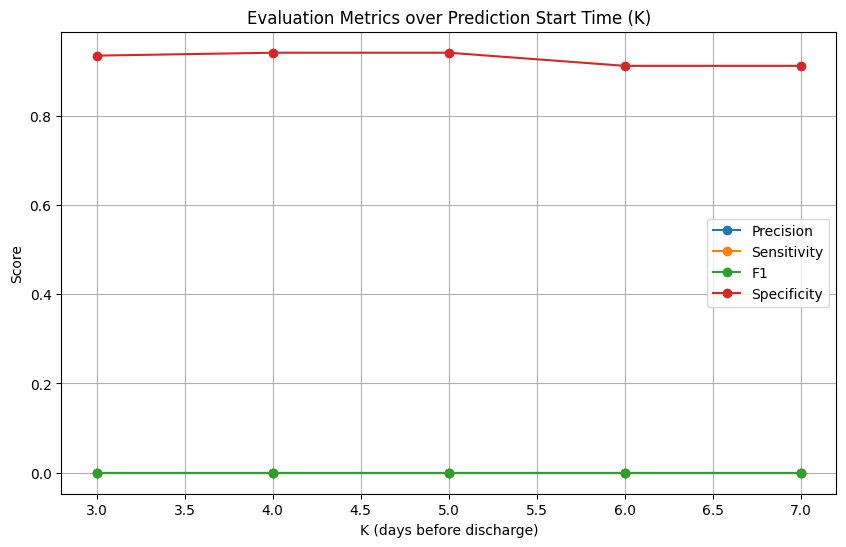

In [11]:
def evaluate_events(true_df, gen_df, outcomes=None, time_bias=48, verbose=False):
    """Evaluate predicted events against true events."""
    if outcomes is None:
        outcomes = dataset_config.TERMINAL_OUTCOMES + dataset_config.OUTCOMES

    def compute_metrics(tp, fp, fn):
        precision = tp / (tp + fp) if (tp + fp) else 0.0
        sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
        f1 = 2 * precision * sensitivity / (precision + sensitivity) if (precision + sensitivity) else 0.0
        return float(precision), float(sensitivity), float(f1)

    def timeaware_counts(df_pc):
        tp_pa = int(df_pc["has_match"].sum())
        fn_pa = int((df_pc["has_true"] & ~df_pc["has_match"]).sum())
        fp_pa = int((df_pc["has_pred"] & ~df_pc["has_match"]).sum())
        tn_pa = int((~df_pc["has_true"] & ~df_pc["has_pred"]).sum())
        return tp_pa, fp_pa, fn_pa, tn_pa

    cutoff_map = gen_df[gen_df["IsInput"] == 1].groupby("PatientId")["TimePoint"].max()
    patients_evaluated = cutoff_map.index.unique()
    num_patients = len(patients_evaluated)

    pred_df = gen_df[(gen_df["IsInput"] == 0) & (gen_df["Token"].isin(outcomes))].copy()
    pred_df = pred_df.rename(columns={"Token": "ConceptName", "TimePoint": "PredTime"})

    true_df = true_df[true_df["RawConcept"].isin(outcomes)].copy()
    true_df = true_df.rename(columns={"RawConcept": "ConceptName", "TimePoint": "TrueTime"})
    true_df = true_df.merge(cutoff_map.rename("CutoffTime"), on="PatientId", how="inner")
    true_df = true_df[true_df["TrueTime"] > true_df["CutoffTime"]].drop(columns=["CutoffTime"])

    merged = true_df.merge(pred_df, on=["PatientId", "ConceptName"], how="outer", indicator=True)
    merged["TP"] = merged["_merge"] == "both"
    merged["FP"] = merged["_merge"] == "right_only"
    merged["FN"] = merged["_merge"] == "left_only"

    any_pairs = merged.loc[:, ["PatientId", "ConceptName"]].dropna().drop_duplicates()
    fp_pairs_overall = merged.loc[merged["FP"], ["PatientId", "ConceptName"]].drop_duplicates()

    merged["TimeErr"] = merged["PredTime"] - merged["TrueTime"]
    merged["TP_timeaware"] = merged["TP"] & (merged["TimeErr"].abs() <= time_bias)

    agg = merged.groupby(["PatientId", "ConceptName"], dropna=False).agg(
        has_true=("TrueTime", lambda s: s.notna().any()),
        has_pred=("PredTime", lambda s: s.notna().any()),
        has_match=("TP_timeaware", "any"),
    ).reset_index()
    agg = agg[agg["ConceptName"].isin(outcomes)]
    full_index = pd.MultiIndex.from_product([patients_evaluated, outcomes], names=["PatientId", "ConceptName"])
    agg = agg.set_index(["PatientId", "ConceptName"]).reindex(full_index, fill_value=False).reset_index()

    results = {"OVERALL": {}, "PER_CLASS": {}}

    for concept in outcomes:
        sub = merged[merged["ConceptName"] == concept]
        tp = int(sub["TP"].sum())
        fp = int(sub["FP"].sum())
        fn = int(sub["FN"].sum())
        p, sens, f1 = compute_metrics(tp, fp, fn)

        patients_with_any = sub["PatientId"].dropna().drop_duplicates().shape[0]
        tn_pc = int(num_patients - patients_with_any)
        fp_pc = int(sub.loc[sub["FP"], ["PatientId"]].dropna().drop_duplicates().shape[0])
        spec = float(tn_pc / (tn_pc + fp_pc)) if (tn_pc + fp_pc) else 0.0

        agg_c = agg[agg["ConceptName"] == concept]
        tpt, fp_t, fn_t, tn_t = timeaware_counts(agg_c)
        _, sens_t, f1_t = compute_metrics(tpt, fp_t, fn_t)
        spec_t = float(tn_t / (tn_t + fp_t)) if (tn_t + fp_t) else 0.0

        results["PER_CLASS"][concept] = {
            "precision": p,
            "sensitivity": sens,
            "specificity": spec,
            "f1": f1,
            "sensitivity_timeaware": sens_t,
            "specificity_timeaware": spec_t,
            "f1_timeaware": f1_t,
            "support": int(tp + fn),
            "total_pred": int(tp + fp),
        }

    tp = int(merged["TP"].sum())
    fp = int(merged["FP"].sum())
    fn = int(merged["FN"].sum())
    p, sens, f1 = compute_metrics(tp, fp, fn)

    tpt, fp_t, fn_t, tn_t = timeaware_counts(agg)
    _, sens_t, f1_t = compute_metrics(tpt, fp_t, fn_t)
    spec_t_overall = float(tn_t / (tn_t + fp_t)) if (tn_t + fp_t) else 0.0

    total_pairs = int(num_patients * len(outcomes))
    tn_total = int(total_pairs - any_pairs.shape[0])
    fp_pairs_total = int(fp_pairs_overall.shape[0])
    spec_overall = float(tn_total / (tn_total + fp_pairs_total)) if (tn_total + fp_pairs_total) else 0.0

    results["OVERALL"] = {
        "f1": float(f1),
        "precision": float(p),
        "sensitivity": float(sens),
        "specificity": float(spec_overall),
        "f1_timeaware": float(f1_t),
        "sensitivity_timeaware": float(sens_t),
        "specificity_timeaware": float(spec_t_overall),
    }

    if verbose:
        print("\n📊 Evaluation Summary:")
        for k, v in results["OVERALL"].items():
            print(f"  {k:24}: {v:.4f}")
        print("\n🔍 Per-Outcome Evaluation:")
        for concept, scores in results["PER_CLASS"].items():
            print(
                f"  {concept:30}: "
                f"F1={scores['f1']:.4f} | "
                f"Sens={scores['sensitivity']:.4f} | "
                f"Spec={scores['specificity']:.4f} | "
                f"TA-Sens={scores['sensitivity_timeaware']:.4f} | "
                f"TA-Spec={scores['specificity_timeaware']:.4f} | "
                f"Support={scores['support']} | Preds={scores['total_pred']}"
            )

    return results

def evaluate_across_k(model, df_all, ctx_df_all, tokenizer, scaler,
                      k_range=range(3, 14), max_len=500, temperature=1.0, time_bias=48):
    """Run inference and evaluation across K-day cutoffs before discharge."""
    results = {}

    full_processor = dataset.DataProcessor(
        df_all.copy(),
        ctx_df_all.copy(),
        scaler=scaler,
        tak_repo_path=dataset_config.TAK_REPO_PATH,
        checkpoint_path=model_config.CHECKPOINT_PATH,
    )
    df_gt, ctx_gt = full_processor.run()
    all_tokens_df = dataset.EMRDataset(df_gt, ctx_gt, tokenizer=tokenizer).tokens_df

    for k in k_range:
        processor = dataset.DataProcessor(
            df_all.copy(),
            ctx_df_all.copy(),
            scaler=scaler,
            tak_repo_path=dataset_config.TAK_REPO_PATH,
            max_input_days=k,
            checkpoint_path=model_config.CHECKPOINT_PATH,
        )
        df_k, ctx_k = processor.run()
        dataset_k = dataset.EMRDataset(df_k, ctx_k, tokenizer=tokenizer)

        gen_df = inference.infer_event_stream(
            model,
            dataset_k,
            max_len=max_len,
            temperature=temperature,
            tqdm_position=0,
            tqdm_desc=f"Generating for k={k}",
        )

        pids = gen_df["PatientId"].unique()
        gold_df = all_tokens_df[all_tokens_df["PatientId"].isin(pids)]

        results[k] = evaluate_events(gold_df, gen_df, time_bias=time_bias, verbose=False)

    return results

def plot_metrics_trend(results):
    ks = sorted(results.keys())
    precision = [results[k]["OVERALL"]["precision"] for k in ks]
    sensitivity = [results[k]["OVERALL"]["sensitivity"] for k in ks]
    f1 = [results[k]["OVERALL"]["f1"] for k in ks]
    specificity = [results[k]["OVERALL"]["specificity"] for k in ks]

    plt.figure(figsize=(10, 6))
    plt.plot(ks, precision, label="Precision", marker="o")
    plt.plot(ks, sensitivity, label="Sensitivity", marker="o")
    plt.plot(ks, f1, label="F1", marker="o")
    plt.plot(ks, specificity, label="Specificity", marker="o")
    plt.xlabel("K (days before discharge)")
    plt.ylabel("Score")
    plt.title("Evaluation Metrics over Prediction Start Time (K)")
    plt.legend()
    plt.grid(True)
    plt.show()

results = evaluate_across_k(
    model=model,
    df_all=eval_temporal_raw.copy(),
    ctx_df_all=eval_ctx_raw.copy(),
    tokenizer=tokenizer,
    scaler=scaler,
    k_range=K_RANGE,
    max_len=MAX_LEN,
    temperature=TEMPERATURE,
    time_bias=TIME_BIAS_HOURS,
 )

plot_metrics_trend(results)

### Output 2: Accuracy per Outcome Type (3 Rows)

In [12]:
def build_3x_matrix(results):
    rows = [dataset_config.RELEASE_TOKEN, dataset_config.DEATH_TOKEN, "COMPLICATION"]
    matrix = {r: [] for r in rows}
    for k in sorted(results):
        per_class = results[k]["PER_CLASS"]

        release_f1 = per_class.get(dataset_config.RELEASE_TOKEN, {}).get("f1", 0.0)
        death_f1 = per_class.get(dataset_config.DEATH_TOKEN, {}).get("f1", 0.0)
        complication_tokens = [t for t in dataset_config.OUTCOMES if t in per_class]
        if complication_tokens:
            comp_f1 = sum(per_class[t].get("f1", 0.0) for t in complication_tokens) / len(complication_tokens)
        else:
            comp_f1 = 0.0

        matrix[dataset_config.RELEASE_TOKEN].append(release_f1)
        matrix[dataset_config.DEATH_TOKEN].append(death_f1)
        matrix["COMPLICATION"].append(comp_f1)

    return pd.DataFrame(matrix, index=sorted(results.keys())).T

build_3x_matrix(results)

,3,4,5,6,7
RELEASE_EVENT,0.0,0.0,0.0,0.0,0.0
DEATH_EVENT,0.0,0.0,0.0,0.0,0.0
COMPLICATION,0.0,0.0,0.0,0.0,0.0


### Output 3: Accuracy per Unique Outcome Label

In [13]:
def build_full_outcome_matrix(results):
    concepts = sorted({c for r in results.values() for c in r["PER_CLASS"]})
    matrix = {c: [] for c in concepts}
    for k in sorted(results):
        for c in concepts:
            f1 = results[k]["PER_CLASS"].get(c, {}).get("f1", 0.0)
            matrix[c].append(f1)
    return pd.DataFrame(matrix, index=sorted(results.keys())).T

build_full_outcome_matrix(results)

,3,4,5,6,7
ACIDOSIS_EVENT,0.0,0.0,0.0,0.0,0.0
ACUTE_RESPIRATORY_DISORDER,0.0,0.0,0.0,0.0,0.0
ATHEROSCLEROSIS_EVENT,0.0,0.0,0.0,0.0,0.0
CARDIO-VASCULAR_DISORDER_EVENT,0.0,0.0,0.0,0.0,0.0
DEATH_EVENT,0.0,0.0,0.0,0.0,0.0
DIABETIC_COMA_EVENT,0.0,0.0,0.0,0.0,0.0
DISGLYCEMIA_EVENT,0.0,0.0,0.0,0.0,0.0
HYPEROSMOLALITY_EVENT,0.0,0.0,0.0,0.0,0.0
INFECTION_EVENT,0.0,0.0,0.0,0.0,0.0
KETOACIDOSIS_EVENT,0.0,0.0,0.0,0.0,0.0


### Output 4: Time-Aware Accuracy Table

In [14]:
def build_timeaware_matrix(results):
    concepts = sorted({c for r in results.values() for c in r["PER_CLASS"]})
    matrix = {c: [] for c in concepts}
    for k in sorted(results):
        for c in concepts:
            f1_t = results[k]["PER_CLASS"].get(c, {}).get("f1_timeaware", 0.0)
            matrix[c].append(f1_t)
    return pd.DataFrame(matrix, index=sorted(results.keys())).T

build_timeaware_matrix(results)

,3,4,5,6,7
ACIDOSIS_EVENT,0.0,0.0,0.0,0.0,0.0
ACUTE_RESPIRATORY_DISORDER,0.0,0.0,0.0,0.0,0.0
ATHEROSCLEROSIS_EVENT,0.0,0.0,0.0,0.0,0.0
CARDIO-VASCULAR_DISORDER_EVENT,0.0,0.0,0.0,0.0,0.0
DEATH_EVENT,0.0,0.0,0.0,0.0,0.0
DIABETIC_COMA_EVENT,0.0,0.0,0.0,0.0,0.0
DISGLYCEMIA_EVENT,0.0,0.0,0.0,0.0,0.0
HYPEROSMOLALITY_EVENT,0.0,0.0,0.0,0.0,0.0
INFECTION_EVENT,0.0,0.0,0.0,0.0,0.0
KETOACIDOSIS_EVENT,0.0,0.0,0.0,0.0,0.0
